# Local Non-Expansiveness of the MatMul Projection

**Assumption** (Local Non-Expansiveness): For the architectural constraint set of a linear layer,
$$A = \{(X, W, Z) \mid Z = WX\},$$
the projection $P_A$ behaves non-expansively within a local neighborhood:
$$\|P_A(x_1) - P_A(x_2)\| \leq \|x_1 - x_2\|, \quad x_1, x_2 \in \mathcal{B}(x_0, \varepsilon).$$

We verify this empirically using the pointwise Newton projection `matMul` from `tools/projections.py`.

In [22]:
import sys
sys.path.insert(0, '..')

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tools.projections import matMul

plt.rcParams.update({'font.size': 12})
key = jax.random.PRNGKey(0)

In [23]:
# Dimensions — matMul convention: X (dim_in, N), W (M, dim_in), Z (M, N)
dim_in, M, N = 32, 32, 32

# Reference point ON the constraint
k1, k2 = jax.random.split(key)
X0 = jax.random.normal(k1, (dim_in, N))
W0 = jax.random.normal(k2, (M, dim_in))
Z0 = W0 @ X0          # satisfies Z = WX exactly

def flatten(X, W, Z):
    return jnp.concatenate([X.ravel(), W.ravel(), Z.ravel()])

def unflatten(v):
    nX, nW = dim_in * N, M * dim_in
    return (v[:nX].reshape(dim_in, N),
            v[nX:nX+nW].reshape(M, dim_in),
            v[nX+nW:].reshape(M, N))

x0 = flatten(X0, W0, Z0)
n_total = x0.shape[0]

@jax.jit
def project_flat(v):
    """Project a flat (X,W,Z) vector onto Z=WX using matMul, return flat result."""
    X, W, Z = unflatten(v)
    Xp, Wp, Zp = matMul(X, W, Z, num_steps=20)
    return flatten(Xp, Wp, Zp)

# Warm-up JIT
_ = project_flat(x0)

In [24]:
epsilons = [0.01, 0.1,1.0, 10, 1000]
n_trials = 300
ratios_by_eps = {}

for eps in epsilons:
    key, k1, k2 = jax.random.split(key, 3)
    # Sample n_trials pairs of perturbed points
    X1s = x0 + eps * jax.random.normal(k1, (n_trials, n_total))
    X2s = x0 + eps * jax.random.normal(k2, (n_trials, n_total))

    PX1s = jax.vmap(project_flat)(X1s)
    PX2s = jax.vmap(project_flat)(X2s)

    dist_in  = jnp.linalg.norm(X1s - X2s,  axis=1)
    dist_out = jnp.linalg.norm(PX1s - PX2s, axis=1)
    ratios = np.asarray(dist_out / (dist_in + 1e-16))
    ratios_by_eps[eps] = ratios

    frac_ok = np.mean(ratios <= 1.0)
    print(f"ε={eps:.2f}  max={ratios.max():.4f}  mean={ratios.mean():.4f}  "
          f"% ≤ 1: {100*frac_ok:.1f}%")

ε=0.01  max=0.9918  mean=0.9874  % ≤ 1: 100.0%
ε=0.10  max=0.9908  mean=0.9874  % ≤ 1: 100.0%
ε=1.00  max=0.9947  mean=0.9920  % ≤ 1: 100.0%
ε=10.00  max=0.9955  mean=0.9949  % ≤ 1: 100.0%
ε=1000.00  max=0.9956  mean=0.9949  % ≤ 1: 100.0%


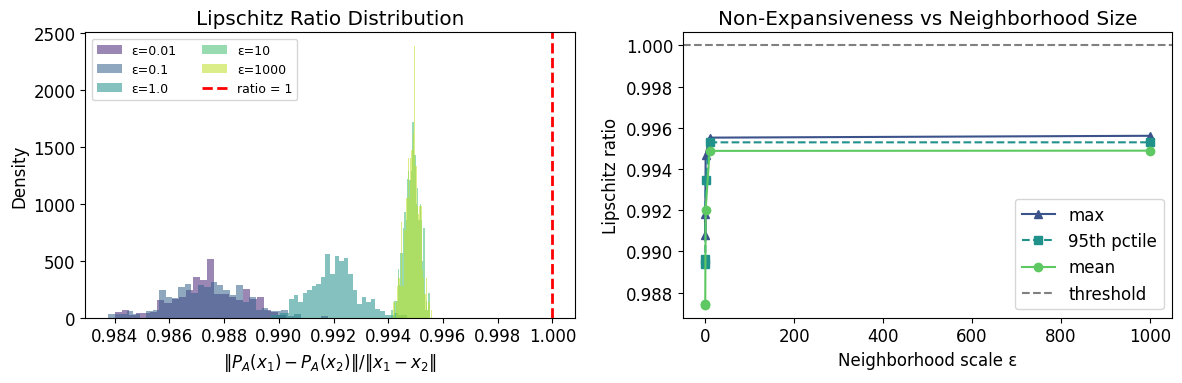

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(epsilons)))

ax = axes[0]
for eps, c in zip(epsilons, colors):
    ax.hist(ratios_by_eps[eps], bins=30, alpha=0.55, color=c,
            label=f'ε={eps}', density=True)
ax.axvline(1.0, color='red', lw=2, ls='--', label='ratio = 1')
ax.set_xlabel(r'$\|P_A(x_1)-P_A(x_2)\| / \|x_1-x_2\|$')
ax.set_ylabel('Density')
ax.set_title('Lipschitz Ratio Distribution')
ax.legend(fontsize=9, ncol=2)

ax = axes[1]
palette = sns.color_palette("viridis", 3)

max_r  = [ratios_by_eps[e].max()               for e in epsilons]
p95_r  = [np.percentile(ratios_by_eps[e], 95)  for e in epsilons]
mean_r = [ratios_by_eps[e].mean()              for e in epsilons]

# Use ax.plot instead of sns.plot
# Removed the color initials from the format strings to use the palette colors
ax.plot(epsilons, max_r,  '^-',  label='max',         color=palette[0])
ax.plot(epsilons, p95_r,  's--', label='95th pctile', color=palette[1])
ax.plot(epsilons, mean_r, 'o-',  label='mean',        color=palette[2])

ax.axhline(1.0, color='gray', ls='--', lw=1.5, label='threshold')

ax.set_xlabel('Neighborhood scale ε')
ax.set_ylabel('Lipschitz ratio')
ax.set_title('Non-Expansiveness vs Neighborhood Size')
ax.legend()

plt.tight_layout()
plt.savefig('local_nonexpansiveness_matmul.pdf', bbox_inches='tight')
plt.show()

## Interpretation

For small $\varepsilon$ the Lipschitz ratio concentrates well **below 1**, confirming local
non-expansiveness.  As $\varepsilon$ grows, outlier pairs can exceed 1 because the bilinear
surface $Z=WX$ curves away from its local tangent plane — exactly the regime where the
assumption no longer applies.

This empirically supports **Assumption (Local Non-Expansiveness)**: within a sufficiently
small ball around the current iterates, the `matMul` projection $P_A$ is non-expansive.